In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [210]:
df = pd.read_csv('Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [211]:
df.shape

(7043, 21)

In [212]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [213]:
df.drop(['customerID'], axis='columns', inplace=True)

In [214]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [216]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [217]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)

In [218]:
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [219]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [220]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [221]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


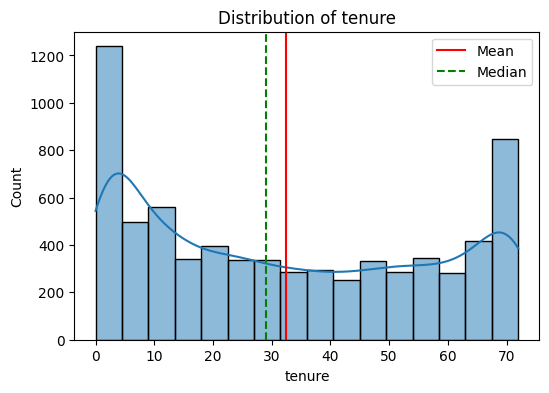

In [222]:
plt.figure(figsize=(6,4))
sns.histplot(df["tenure"], edgecolor="black", kde=True)
plt.title("Distribution of tenure")
plt.axvline(df["tenure"].mean(), color="red", linestyle="-", label="Mean")
plt.axvline(df["tenure"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.show()

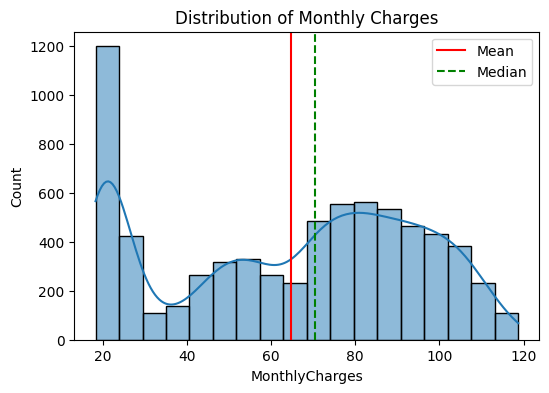

In [223]:
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyCharges"], edgecolor="black", kde=True)
plt.title("Distribution of Monthly Charges")
plt.axvline(df["MonthlyCharges"].mean(), color="red", linestyle="-", label="Mean")
plt.axvline(df["MonthlyCharges"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.show()

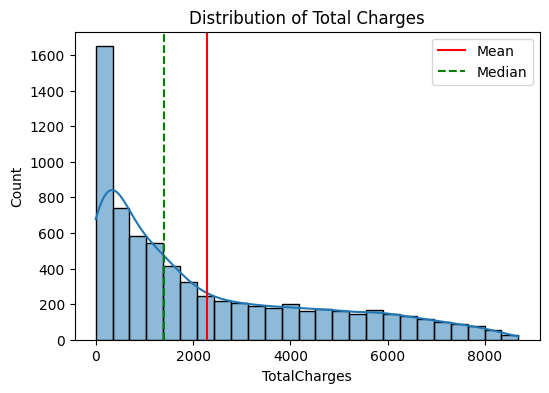

In [224]:
plt.figure(figsize=(6,4))
sns.histplot(df["TotalCharges"], edgecolor="black", kde=True)
plt.title("Distribution of Total Charges")
plt.axvline(df["TotalCharges"].mean(), color="red", linestyle="-", label="Mean")
plt.axvline(df["TotalCharges"].median(), color="green", linestyle="--", label="Median")
plt.legend()
plt.show()

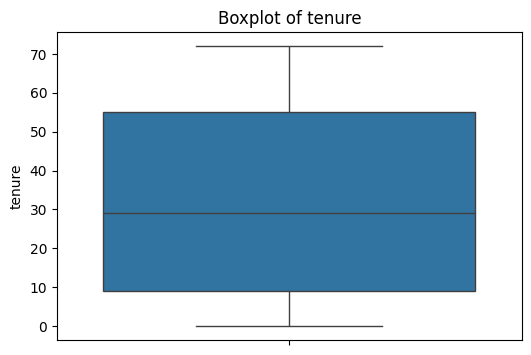

In [225]:
plt.figure(figsize=(6,4))
sns.boxplot(df["tenure"])
plt.title("Boxplot of tenure")
plt.show()

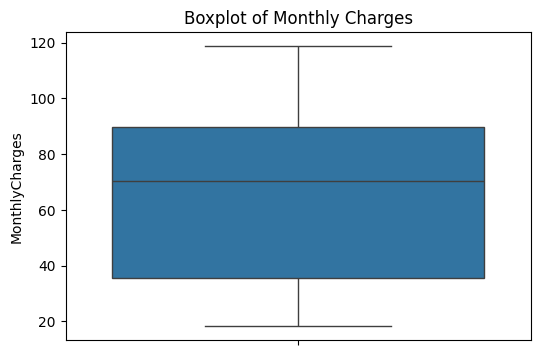

In [226]:
plt.figure(figsize=(6,4))
sns.boxplot(df["MonthlyCharges"])
plt.title("Boxplot of Monthly Charges")
plt.show()

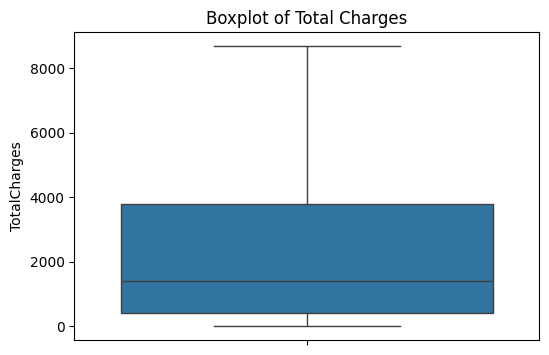

In [227]:
plt.figure(figsize=(6,4))
sns.boxplot(df["TotalCharges"])
plt.title("Boxplot of Total Charges")
plt.show()

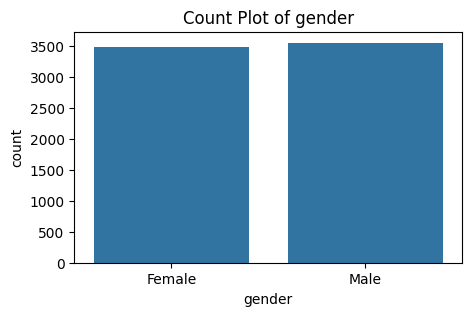

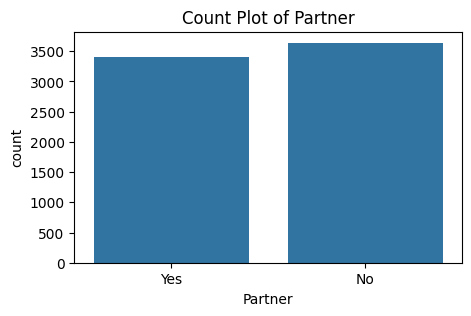

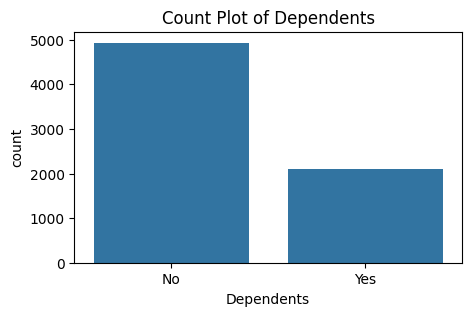

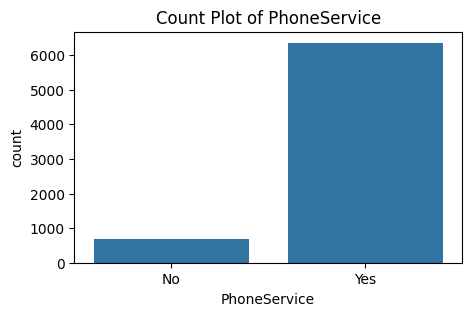

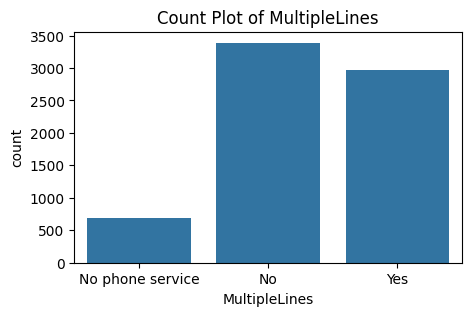

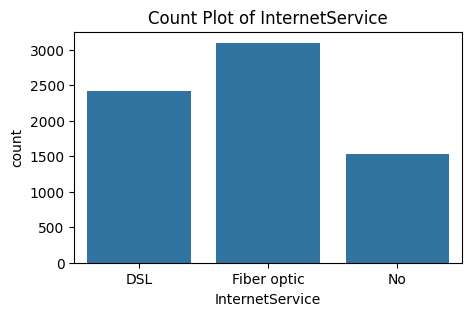

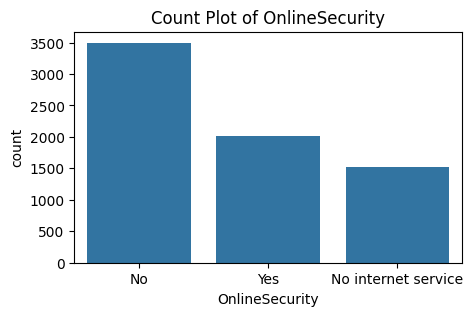

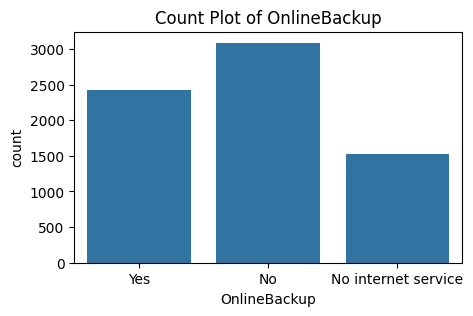

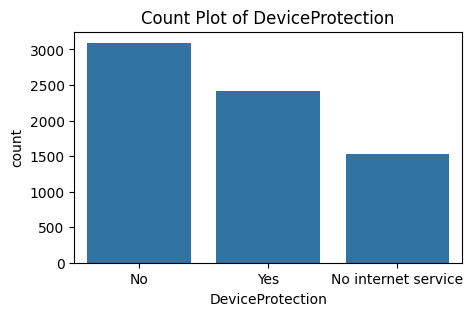

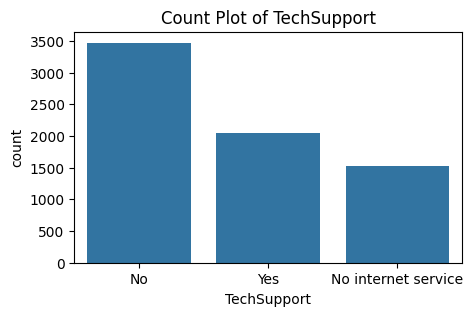

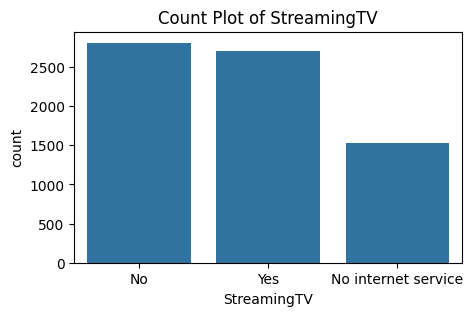

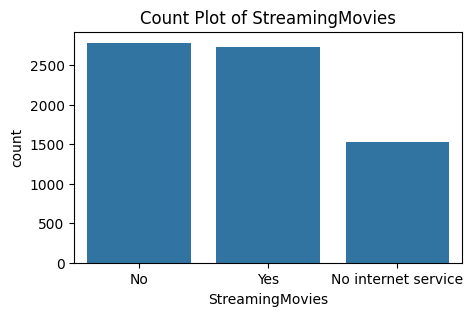

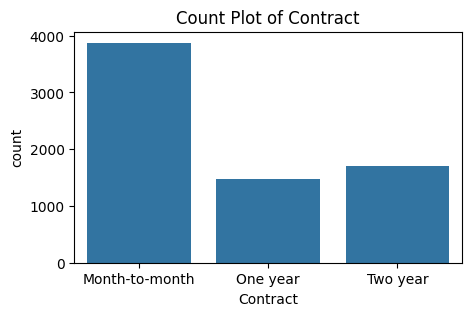

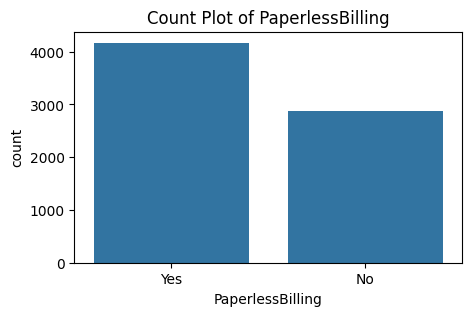

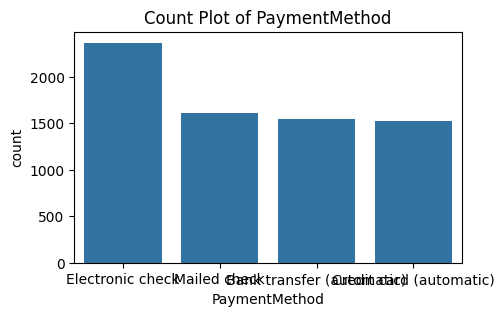

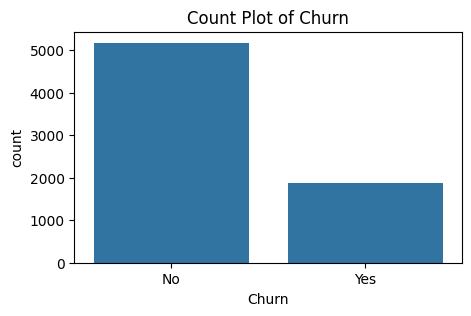

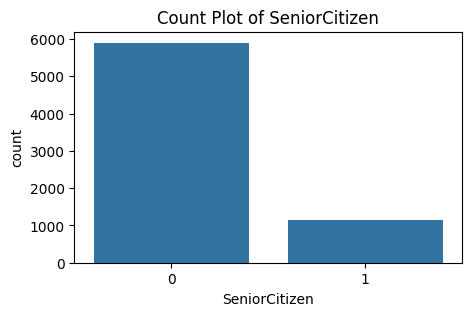

In [228]:
object_cols = df.select_dtypes(include="object").columns.to_list()
object_cols = object_cols + ["SeniorCitizen"]

for col in object_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

In [229]:
df["Churn"] = df["Churn"].replace({"Yes":1, "No":0}).infer_objects(copy=False)

C:\Users\gk333\AppData\Local\Temp\ipykernel_12220\860390701.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes":1, "No":0}).infer_objects(copy=False)


In [230]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [231]:
encoders = {}

for col in object_cols:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [232]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder(),
 'SeniorCitizen': LabelEncoder()}

In [233]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [234]:
X = df.drop(columns = ["Churn"])
y = df["Churn"]

In [235]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [236]:
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [237]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [238]:
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [239]:
models = {
    "Logistic Regression":LogisticRegression(random_state=42, max_iter=5000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42, eval_metric="logloss")
}

In [240]:
cv_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name}")
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
    print("_"*50)

Training Logistic Regression
Logistic Regression cross-validation accuracy: 0.79
__________________________________________________
Training Decision Tree
Decision Tree cross-validation accuracy: 0.78
__________________________________________________
Training Random Forest
Random Forest cross-validation accuracy: 0.84
__________________________________________________
Training XGBoost
XGBoost cross-validation accuracy: 0.83
__________________________________________________


In [241]:
rfc = RandomForestClassifier()
rfc.fit(X_train_smote, y_train_smote)
y_test_pred = rfc.predict(X_test)

In [242]:
print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7778566359119943
Confusion Matrix:
 [[874 162]
 [151 222]]
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1036
           1       0.58      0.60      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [243]:
model_data = {"model":rfc, "features_name":X.columns.to_list()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)